# Mutual Fund Analytics Platform - Performance Analytics
## Bluestock Fintech Capstone | Day 4
**Metrics:** Daily Returns, CAGR, Sharpe, Sortino, Alpha, Beta, Max Drawdown, Fund Scorecard
**Rf = 6.5% (RBI repo rate proxy) | Annualisation = 252 trading days**

## Cell 1 - Setup & Imports

In [2]:
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

PROJECT_ROOT = Path(r'D:\bluestock_mf_platform')
RAW_DIR      = PROJECT_ROOT / 'data' / 'raw'
PROC_DIR     = PROJECT_ROOT / 'data' / 'processed'
CHARTS_DIR   = PROJECT_ROOT / 'reports' / 'charts'
CHARTS_DIR.mkdir(parents=True, exist_ok=True)
PROC_DIR.mkdir(parents=True, exist_ok=True)

RF_ANNUAL  = 0.065
RF_DAILY   = RF_ANNUAL / 252
TRADING_DAYS = 252
ACCENT = '#00C9A7'
sns.set_theme(style='darkgrid', palette='muted', font_scale=1.1)

print('RF Annual  :', RF_ANNUAL)
print('RF Daily   :', round(RF_DAILY, 6))
print('Setup complete')


RF Annual  : 0.065
RF Daily   : 0.000258
Setup complete


## Cell 2 - Load Data

In [3]:
nav_df   = pd.read_csv(RAW_DIR / '02_nav_history.csv',       parse_dates=['date'])
fund_df  = pd.read_csv(RAW_DIR / '01_fund_master.csv',       parse_dates=['launch_date'])
bench_df = pd.read_csv(RAW_DIR / '10_benchmark_indices.csv', parse_dates=['date'])
perf_df  = pd.read_csv(RAW_DIR / '07_scheme_performance.csv')

nav_df = nav_df.sort_values(['amfi_code', 'date']).reset_index(drop=True)

print('nav_df   :', nav_df.shape)
print('fund_df  :', fund_df.shape)
print('bench_df :', bench_df.shape)
print('Indices  :', bench_df['index_name'].unique().tolist())
print('Date range:', nav_df['date'].min().date(), '->', nav_df['date'].max().date())
print('Data loaded OK')


nav_df   : (46000, 3)
fund_df  : (40, 15)
bench_df : (8050, 3)
Indices  : ['NIFTY50', 'NIFTY100', 'NIFTY_MIDCAP150', 'BSE_SMALLCAP', 'NIFTY500', 'CRISIL_LIQUID', 'CRISIL_GILT']
Date range: 2022-01-03 -> 2026-05-29
Data loaded OK


---
## Task 1 - Daily Returns
**Formula:** daily_return = (NAV_t / NAV_t-1) - 1
**Validation:** Distribution should be approximately normal with mean near 0

Daily Return Statistics:
  Mean   : 0.0631 %
  Std    : 1.029 %
  Min    : -5.8102 %
  Max    : 6.4713 %
  Nulls  : 40


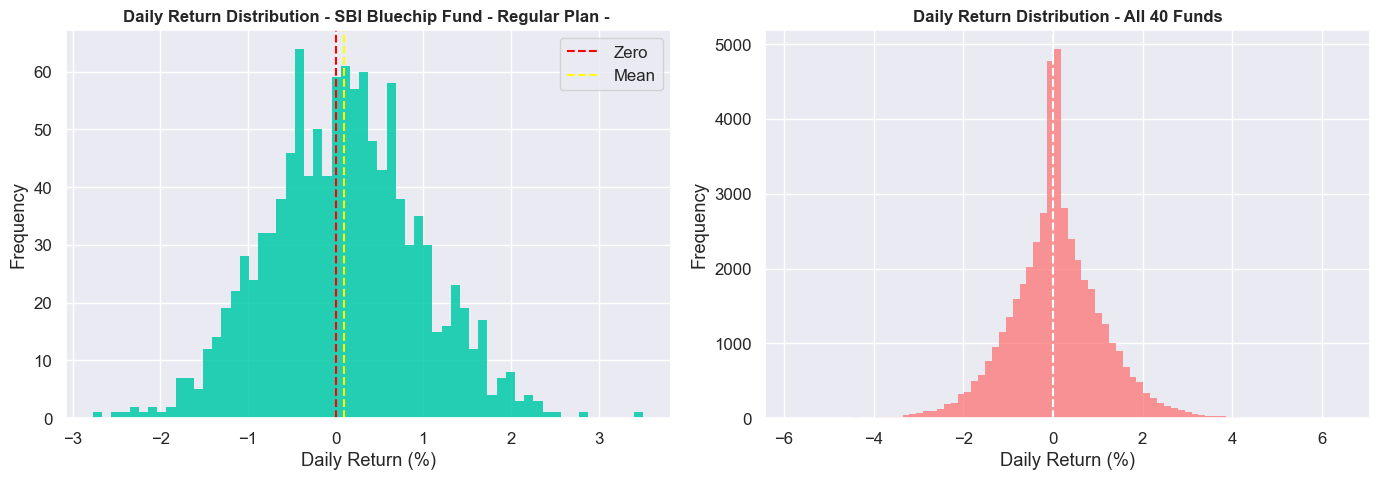

Chart saved: 10_daily_return_distribution.png


In [4]:
nav_df['daily_return'] = nav_df.groupby('amfi_code')['nav'].pct_change()

all_returns = nav_df['daily_return'].dropna()
print('Daily Return Statistics:')
print('  Mean   :', round(all_returns.mean() * 100, 4), '%')
print('  Std    :', round(all_returns.std() * 100, 4), '%')
print('  Min    :', round(all_returns.min() * 100, 4), '%')
print('  Max    :', round(all_returns.max() * 100, 4), '%')
print('  Nulls  :', nav_df['daily_return'].isnull().sum())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sample_code = 119551
sample_name = fund_df[fund_df['amfi_code'] == sample_code]['scheme_name'].values[0][:35]
sample_ret  = nav_df[nav_df['amfi_code'] == sample_code]['daily_return'].dropna()

axes[0].hist(sample_ret * 100, bins=60, color=ACCENT, edgecolor='none', alpha=0.85)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero')
axes[0].axvline(sample_ret.mean() * 100, color='yellow', linestyle='--', linewidth=1.5, label='Mean')
axes[0].set_title('Daily Return Distribution - ' + sample_name, fontsize=12, fontweight='bold')
axes[0].set_xlabel('Daily Return (%)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].hist(all_returns * 100, bins=80, color='#FF6B6B', edgecolor='none', alpha=0.7)
axes[1].axvline(0, color='white', linestyle='--', linewidth=1.5)
axes[1].set_title('Daily Return Distribution - All 40 Funds', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Daily Return (%)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig(CHARTS_DIR / '10_daily_return_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: 10_daily_return_distribution.png')


---
## Task 2 - CAGR Computation
**Formula:** CAGR = (NAV_end / NAV_start) ^ (1/n) - 1
**Periods:** 1yr, 3yr, full-period (Jan 2022 to May 2026)

CAGR Comparison Table (Top 10 by 3yr CAGR):
                                       scheme_name  cagr_1yr_pct  cagr_3yr_pct  cagr_full_pct
               Axis Midcap Fund - Regular - Growth         22.26         35.11          28.21
     Mirae Asset Large Cap Fund - Regular - Growth         20.36         34.00          30.97
         ICICI Pru Bluechip Fund - Direct - Growth         13.06         32.49          23.30
HDFC Mid-Cap Opportunities Fund - Regular - Growth         53.23         32.44          30.12
          ICICI Pru Midcap Fund - Regular - Growth         29.60         31.78          32.83
         SBI Bluechip Fund - Regular Plan - Growth         60.44         30.46          25.80
            Kotak Flexicap Fund - Regular - Growth         26.66         29.58          30.91
     Mirae Asset Tax Saver Fund - Regular - Growth         39.75         29.18          31.95
     ABSL Frontline Equity Fund - Regular - Growth         47.92         28.97          23.54
             DSP

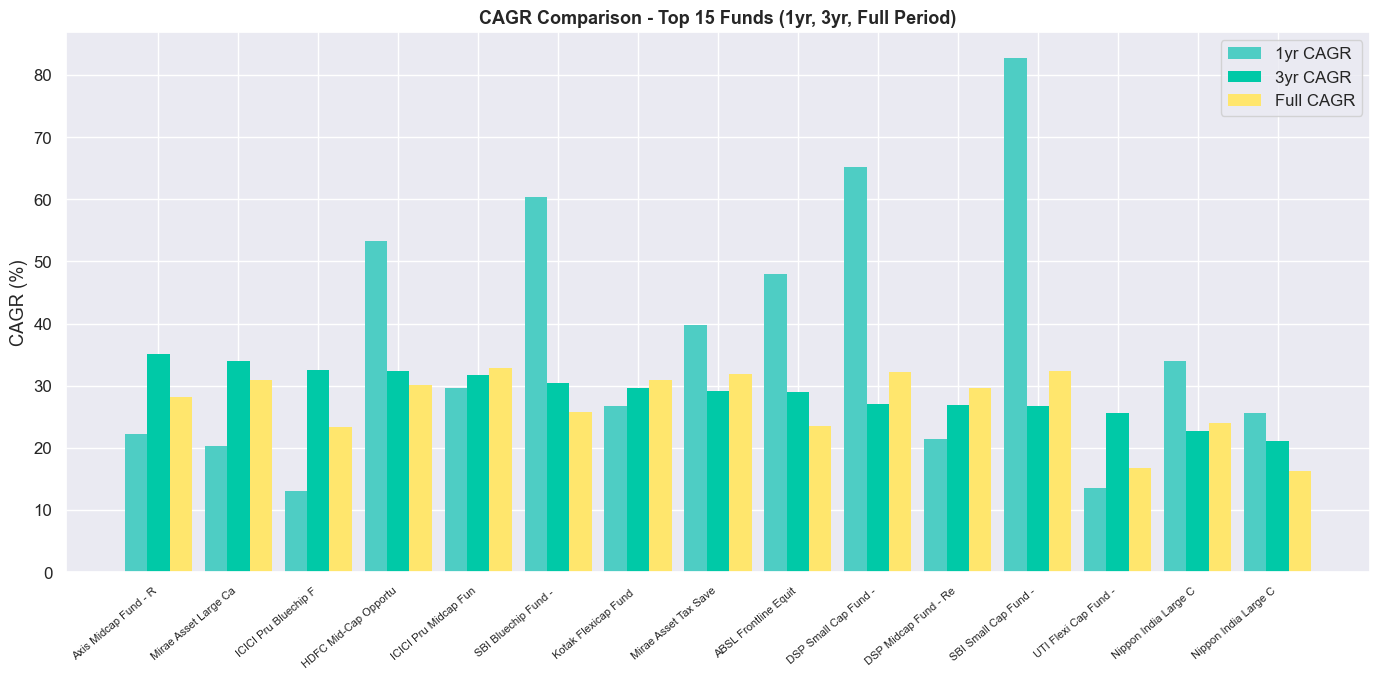

Chart saved: 11_cagr_comparison.png


In [5]:
from datetime import timedelta

def compute_cagr(nav_series, dates, years):
    end_date   = dates.max()
    start_date = end_date - pd.DateOffset(years=years)
    nav_end    = nav_series[dates == end_date]
    nav_start  = nav_series[dates >= start_date].iloc[:1] if len(nav_series[dates >= start_date]) > 0 else None
    if nav_end.empty or nav_start is None or nav_start.empty:
        return np.nan
    return (nav_end.values[0] / nav_start.values[0]) ** (1 / years) - 1

cagr_rows = []
for code in nav_df['amfi_code'].unique():
    sub   = nav_df[nav_df['amfi_code'] == code].copy()
    dates = sub['date']
    navs  = sub['nav']

    nav_start_full = navs.iloc[0]
    nav_end_full   = navs.iloc[-1]
    n_years        = (dates.iloc[-1] - dates.iloc[0]).days / 365.25
    cagr_full      = (nav_end_full / nav_start_full) ** (1 / n_years) - 1

    end_dt   = dates.max()
    st_1yr   = end_dt - pd.DateOffset(years=1)
    st_3yr   = end_dt - pd.DateOffset(years=3)

    sub_1yr = sub[sub['date'] >= st_1yr]
    sub_3yr = sub[sub['date'] >= st_3yr]

    cagr_1yr = ((sub_1yr['nav'].iloc[-1] / sub_1yr['nav'].iloc[0]) ** (1/1) - 1) if len(sub_1yr) > 1 else np.nan
    cagr_3yr = ((sub_3yr['nav'].iloc[-1] / sub_3yr['nav'].iloc[0]) ** (1/3) - 1) if len(sub_3yr) > 1 else np.nan

    name = fund_df[fund_df['amfi_code'] == code]['scheme_name'].values
    fh   = fund_df[fund_df['amfi_code'] == code]['fund_house'].values
    cat  = fund_df[fund_df['amfi_code'] == code]['category'].values

    cagr_rows.append({
        'amfi_code'   : code,
        'scheme_name' : name[0] if len(name) else str(code),
        'fund_house'  : fh[0]   if len(fh)   else '',
        'category'    : cat[0]  if len(cat)   else '',
        'cagr_1yr_pct': round(cagr_1yr * 100, 2) if not np.isnan(cagr_1yr) else np.nan,
        'cagr_3yr_pct': round(cagr_3yr * 100, 2) if not np.isnan(cagr_3yr) else np.nan,
        'cagr_full_pct': round(cagr_full * 100, 2),
    })

cagr_df = pd.DataFrame(cagr_rows).sort_values('cagr_3yr_pct', ascending=False).reset_index(drop=True)

print('CAGR Comparison Table (Top 10 by 3yr CAGR):')
print(cagr_df[['scheme_name','cagr_1yr_pct','cagr_3yr_pct','cagr_full_pct']].head(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(14, 7))
top15 = cagr_df.head(15).copy()
x = range(len(top15))
w = 0.28
ax.bar([i - w for i in x], top15['cagr_1yr_pct'],  width=w, label='1yr CAGR',  color='#4ECDC4', edgecolor='none')
ax.bar([i     for i in x], top15['cagr_3yr_pct'],  width=w, label='3yr CAGR',  color=ACCENT,    edgecolor='none')
ax.bar([i + w for i in x], top15['cagr_full_pct'], width=w, label='Full CAGR', color='#FFE66D', edgecolor='none')
ax.set_xticks(list(x))
ax.set_xticklabels([s[:20] for s in top15['scheme_name']], rotation=40, ha='right', fontsize=8)
ax.set_title('CAGR Comparison - Top 15 Funds (1yr, 3yr, Full Period)', fontsize=13, fontweight='bold')
ax.set_ylabel('CAGR (%)')
ax.axhline(0, color='white', linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.savefig(CHARTS_DIR / '11_cagr_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: 11_cagr_comparison.png')


---
## Task 3 - Sharpe Ratio
**Formula:** Sharpe = (Rp - Rf) / Std(Rp) x sqrt(252)
**Rf = 6.5% annual = 0.0258% daily (RBI repo rate proxy)**

Sharpe Ratio Ranking (All Funds):
 sharpe_rank                                   scheme_name    plan  sharpe_ratio  mean_ret_ann  std_ann
           1 Mirae Asset Large Cap Fund - Regular - Growth Regular        1.4483         27.06    14.19
           2        Kotak Flexicap Fund - Regular - Growth Regular        1.3067         27.26    15.89
           3 Mirae Asset Tax Saver Fund - Regular - Growth Regular        1.2349         28.33    17.67
           4     SBI Bluechip Fund - Regular Plan - Growth Regular        1.2083         23.10    13.74
           5      ICICI Pru Midcap Fund - Regular - Growth Regular        1.1801         29.27    19.29
           6            DSP Midcap Fund - Regular - Growth Regular        1.1321         26.59    17.75
           7 HDFC Mid-Cap Opportunities Fund - Regular - G Regular        1.0937         27.21    18.94
           8 Nippon India Large Cap Fund - Regular - Growt Regular        1.0817         21.80    14.15
           9 ABSL Frontline Eq

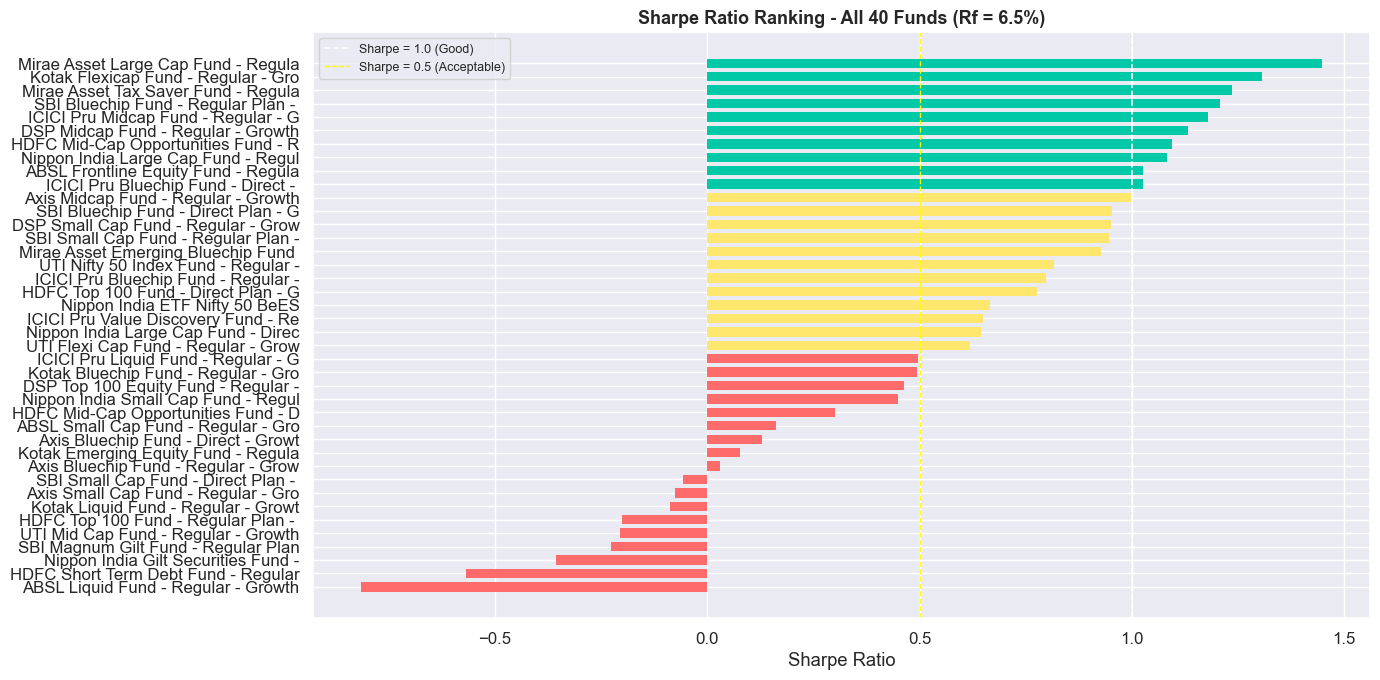

Chart saved: 12_sharpe_ratio_ranking.png


In [6]:
sharpe_rows = []
for code in nav_df['amfi_code'].unique():
    ret = nav_df[nav_df['amfi_code'] == code]['daily_return'].dropna()
    if len(ret) < 50:
        continue
    excess_return = ret.mean() - RF_DAILY
    std_return    = ret.std()
    sharpe = (excess_return / std_return) * np.sqrt(TRADING_DAYS) if std_return > 0 else np.nan
    name = fund_df[fund_df['amfi_code'] == code]['scheme_name'].values
    plan = fund_df[fund_df['amfi_code'] == code]['plan'].values
    cat  = fund_df[fund_df['amfi_code'] == code]['category'].values
    sharpe_rows.append({
        'amfi_code'    : code,
        'scheme_name'  : name[0][:45] if len(name) else str(code),
        'plan'         : plan[0] if len(plan) else '',
        'category'     : cat[0]  if len(cat)  else '',
        'mean_ret_ann' : round(ret.mean() * TRADING_DAYS * 100, 2),
        'std_ann'      : round(ret.std()  * np.sqrt(TRADING_DAYS) * 100, 2),
        'sharpe_ratio' : round(sharpe, 4),
    })

sharpe_df = pd.DataFrame(sharpe_rows).sort_values('sharpe_ratio', ascending=False).reset_index(drop=True)
sharpe_df['sharpe_rank'] = range(1, len(sharpe_df) + 1)

print('Sharpe Ratio Ranking (All Funds):')
print(sharpe_df[['sharpe_rank','scheme_name','plan','sharpe_ratio','mean_ret_ann','std_ann']].to_string(index=False))

fig, ax = plt.subplots(figsize=(14, 7))
colors = ['#00C9A7' if s > 1.0 else '#FFE66D' if s > 0.5 else '#FF6B6B' for s in sharpe_df['sharpe_ratio']]
ax.barh(sharpe_df['scheme_name'].str[:35][::-1], sharpe_df['sharpe_ratio'][::-1], color=colors[::-1], edgecolor='none', height=0.7)
ax.axvline(1.0, color='white',  linestyle='--', linewidth=1.2, label='Sharpe = 1.0 (Good)')
ax.axvline(0.5, color='yellow', linestyle='--', linewidth=1.0, label='Sharpe = 0.5 (Acceptable)')
ax.set_title('Sharpe Ratio Ranking - All 40 Funds (Rf = 6.5%)', fontsize=13, fontweight='bold')
ax.set_xlabel('Sharpe Ratio')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(CHARTS_DIR / '12_sharpe_ratio_ranking.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: 12_sharpe_ratio_ranking.png')


---
## Task 4 - Sortino Ratio
**Formula:** Sortino = (Rp - Rf) / Downside_Std x sqrt(252)
**Downside Std = Std of negative return days only**

Sortino Ratio Ranking (Top 15):
 sortino_rank                                   scheme_name  sortino_ratio  downside_std_ann  pct_neg_days
            1 Mirae Asset Large Cap Fund - Regular - Growth         2.3856              8.62          44.0
            2        Kotak Flexicap Fund - Regular - Growth         2.3643              8.78          46.5
            3 Mirae Asset Tax Saver Fund - Regular - Growth         2.1469             10.17          47.4
            4     SBI Bluechip Fund - Regular Plan - Growth         2.1403              7.76          45.1
            5      ICICI Pru Midcap Fund - Regular - Growth         2.0294             11.22          46.9
            6            DSP Midcap Fund - Regular - Growth         1.8751             10.71          45.8
            7 Nippon India Large Cap Fund - Regular - Growt         1.8501              8.27          46.3
            8 HDFC Mid-Cap Opportunities Fund - Regular - G         1.8291             11.32          46.8
     

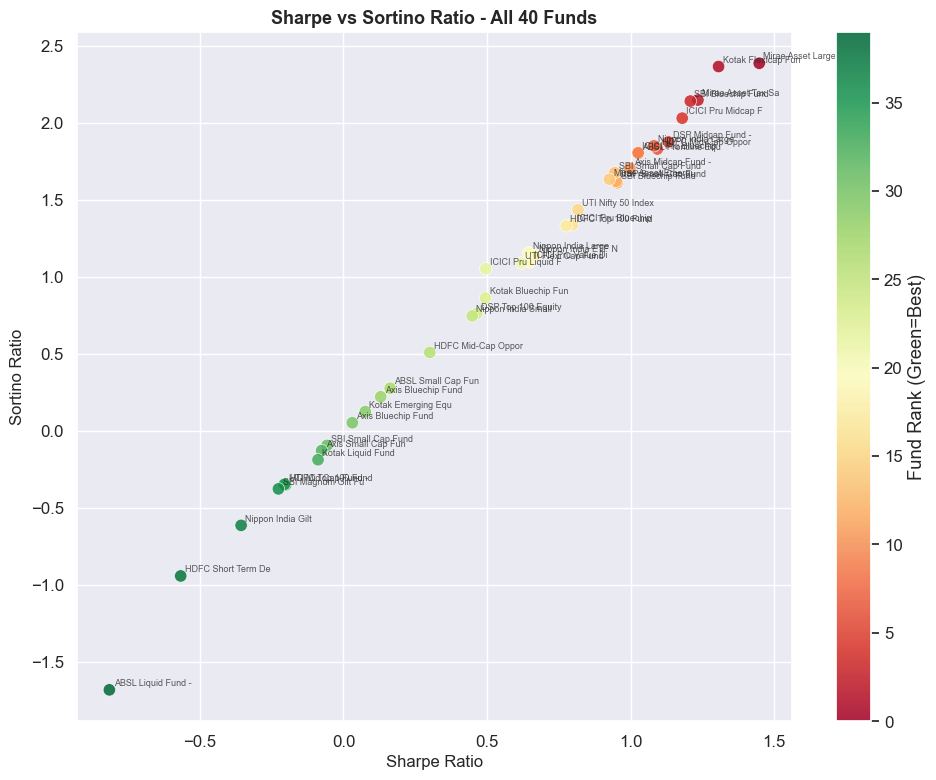

Chart saved: 13_sharpe_vs_sortino.png


In [7]:
sortino_rows = []
for code in nav_df['amfi_code'].unique():
    ret      = nav_df[nav_df['amfi_code'] == code]['daily_return'].dropna()
    downside = ret[ret < 0]
    if len(ret) < 50 or len(downside) < 5:
        continue
    excess_return = ret.mean() - RF_DAILY
    down_std      = downside.std()
    sortino = (excess_return / down_std) * np.sqrt(TRADING_DAYS) if down_std > 0 else np.nan
    name = fund_df[fund_df['amfi_code'] == code]['scheme_name'].values
    sortino_rows.append({
        'amfi_code'      : code,
        'scheme_name'    : name[0][:45] if len(name) else str(code),
        'sortino_ratio'  : round(sortino, 4),
        'downside_std_ann': round(down_std * np.sqrt(TRADING_DAYS) * 100, 2),
        'neg_return_days': len(downside),
        'pct_neg_days'   : round(len(downside) / len(ret) * 100, 1),
    })

sortino_df = pd.DataFrame(sortino_rows).sort_values('sortino_ratio', ascending=False).reset_index(drop=True)
sortino_df['sortino_rank'] = range(1, len(sortino_df) + 1)

print('Sortino Ratio Ranking (Top 15):')
print(sortino_df[['sortino_rank','scheme_name','sortino_ratio','downside_std_ann','pct_neg_days']].head(15).to_string(index=False))

merged_ratios = sharpe_df[['amfi_code','scheme_name','sharpe_ratio']].merge(sortino_df[['amfi_code','sortino_ratio']], on='amfi_code')

fig, ax = plt.subplots(figsize=(10, 8))
sc = ax.scatter(merged_ratios['sharpe_ratio'], merged_ratios['sortino_ratio'],
                c=range(len(merged_ratios)), cmap='RdYlGn', s=80, alpha=0.85, edgecolors='white', linewidths=0.5)
for _, row in merged_ratios.iterrows():
    ax.annotate(row['scheme_name'][:18], (row['sharpe_ratio'], row['sortino_ratio']),
                fontsize=6.5, alpha=0.75, xytext=(3, 3), textcoords='offset points')
ax.set_xlabel('Sharpe Ratio', fontsize=12)
ax.set_ylabel('Sortino Ratio', fontsize=12)
ax.set_title('Sharpe vs Sortino Ratio - All 40 Funds', fontsize=13, fontweight='bold')
ax.axhline(0, color='white', linewidth=0.6, linestyle='--')
ax.axvline(0, color='white', linewidth=0.6, linestyle='--')
plt.colorbar(sc, label='Fund Rank (Green=Best)')
plt.tight_layout()
plt.savefig(CHARTS_DIR / '13_sharpe_vs_sortino.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: 13_sharpe_vs_sortino.png')


---
## Task 5 - Alpha and Beta
**Method:** OLS regression of fund daily returns on NIFTY100 daily returns
**Formula:** fund_return = alpha_daily + beta x benchmark_return
**Alpha annualised = intercept x 252**

Alpha & Beta Table (sorted by Alpha):
                                  scheme_name  alpha_ann_pct    beta  r_squared  p_value
   SBI Small Cap Fund - Regular Plan - Growth        30.3370 -0.0232     0.0001   0.6872
        DSP Small Cap Fund - Regular - Growth        30.0579  0.0115     0.0000   0.8405
     ICICI Pru Midcap Fund - Regular - Growth        29.2636  0.0005     0.0000   0.9901
Mirae Asset Tax Saver Fund - Regular - Growth        28.2704  0.0181     0.0002   0.6543
       Kotak Flexicap Fund - Regular - Growth        27.3305 -0.0228     0.0003   0.5305
HDFC Mid-Cap Opportunities Fund - Regular - G        27.1954  0.0051     0.0000   0.9064
Mirae Asset Large Cap Fund - Regular - Growth        26.9838  0.0237     0.0005   0.4664
           DSP Midcap Fund - Regular - Growth        26.5986 -0.0025     0.0000   0.9505
          Axis Midcap Fund - Regular - Growth        26.0767 -0.0663     0.0019   0.1360
    SBI Bluechip Fund - Regular Plan - Growth        23.2010 -0.0318    

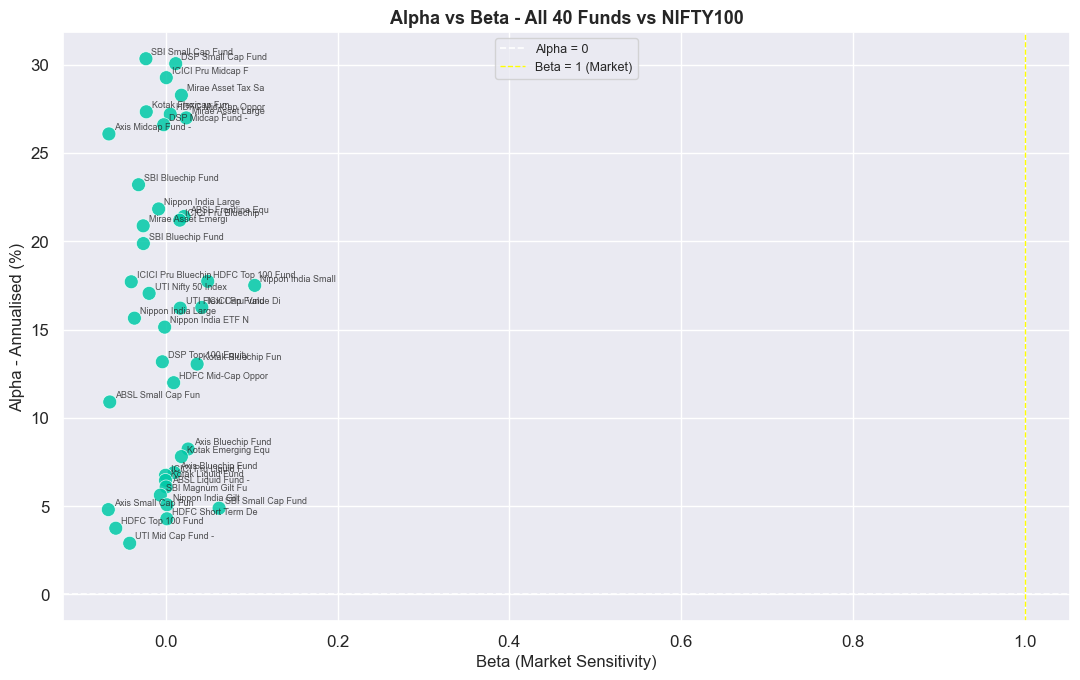

Chart saved: 14_alpha_beta_scatter.png


In [8]:
nifty100 = bench_df[bench_df['index_name'] == 'NIFTY100'].copy()
nifty100 = nifty100.sort_values('date')
nifty100['bench_return'] = nifty100['close_value'].pct_change()
nifty100 = nifty100.dropna(subset=['bench_return'])

ab_rows = []
for code in nav_df['amfi_code'].unique():
    sub = nav_df[nav_df['amfi_code'] == code][['date','daily_return']].dropna()
    merged = sub.merge(nifty100[['date','bench_return']], on='date')
    if len(merged) < 100:
        continue
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        merged['bench_return'], merged['daily_return']
    )
    beta         = slope
    alpha_annual = intercept * TRADING_DAYS * 100
    r_squared    = r_value ** 2
    name  = fund_df[fund_df['amfi_code'] == code]['scheme_name'].values
    fh    = fund_df[fund_df['amfi_code'] == code]['fund_house'].values
    plan  = fund_df[fund_df['amfi_code'] == code]['plan'].values
    cat   = fund_df[fund_df['amfi_code'] == code]['category'].values
    ab_rows.append({
        'amfi_code'    : code,
        'scheme_name'  : name[0][:45] if len(name) else str(code),
        'fund_house'   : fh[0]   if len(fh)   else '',
        'plan'         : plan[0] if len(plan) else '',
        'category'     : cat[0]  if len(cat)  else '',
        'alpha_ann_pct': round(alpha_annual, 4),
        'beta'         : round(beta, 4),
        'r_squared'    : round(r_squared, 4),
        'p_value'      : round(p_value, 4),
        'observations' : len(merged),
    })

ab_df = pd.DataFrame(ab_rows).sort_values('alpha_ann_pct', ascending=False).reset_index(drop=True)

print('Alpha & Beta Table (sorted by Alpha):')
print(ab_df[['scheme_name','alpha_ann_pct','beta','r_squared','p_value']].to_string(index=False))

ab_df.to_csv(PROC_DIR / 'alpha_beta.csv', index=False)
print('Saved: alpha_beta.csv')

fig, ax = plt.subplots(figsize=(11, 7))
colors_ab = ['#00C9A7' if a > 0 else '#FF6B6B' for a in ab_df['alpha_ann_pct']]
ax.scatter(ab_df['beta'], ab_df['alpha_ann_pct'], c=colors_ab, s=100, alpha=0.85, edgecolors='white', linewidths=0.5)
for _, row in ab_df.iterrows():
    ax.annotate(row['scheme_name'][:18], (row['beta'], row['alpha_ann_pct']),
                fontsize=6.5, alpha=0.8, xytext=(4, 3), textcoords='offset points')
ax.axhline(0, color='white', linestyle='--', linewidth=1.2, label='Alpha = 0')
ax.axvline(1, color='yellow', linestyle='--', linewidth=1.0, label='Beta = 1 (Market)')
ax.set_xlabel('Beta (Market Sensitivity)', fontsize=12)
ax.set_ylabel('Alpha - Annualised (%)', fontsize=12)
ax.set_title('Alpha vs Beta - All 40 Funds vs NIFTY100', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(CHARTS_DIR / '14_alpha_beta_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: 14_alpha_beta_scatter.png')


---
## Task 6 - Maximum Drawdown
**Formula:** Max Drawdown = min(NAV / running_max - 1)
**Also finds the drawdown start date, trough date, and recovery**

Maximum Drawdown - Worst 10 Funds:
                                  scheme_name    plan  max_drawdown_pct  peak_date trough_date  drawdown_days
    SBI Small Cap Fund - Direct Plan - Growth  Direct            -52.57 2023-01-17  2025-10-28            725
       Axis Small Cap Fund - Regular - Growth Regular            -51.68 2025-05-22  2026-05-11            252
       ABSL Small Cap Fund - Regular - Growth Regular            -35.45 2024-11-21  2026-05-11            382
        DSP Small Cap Fund - Regular - Growth Regular            -31.17 2024-05-03  2025-01-03            175
   SBI Small Cap Fund - Regular Plan - Growth Regular            -28.71 2024-08-28  2025-05-14            185
          UTI Mid Cap Fund - Regular - Growth Regular            -28.00 2025-01-07  2026-04-27            339
    HDFC Top 100 Fund - Regular Plan - Growth Regular            -24.73 2022-03-30  2022-09-15            121
Kotak Emerging Equity Fund - Regular - Growth Regular            -24.00 2023-11-09  2

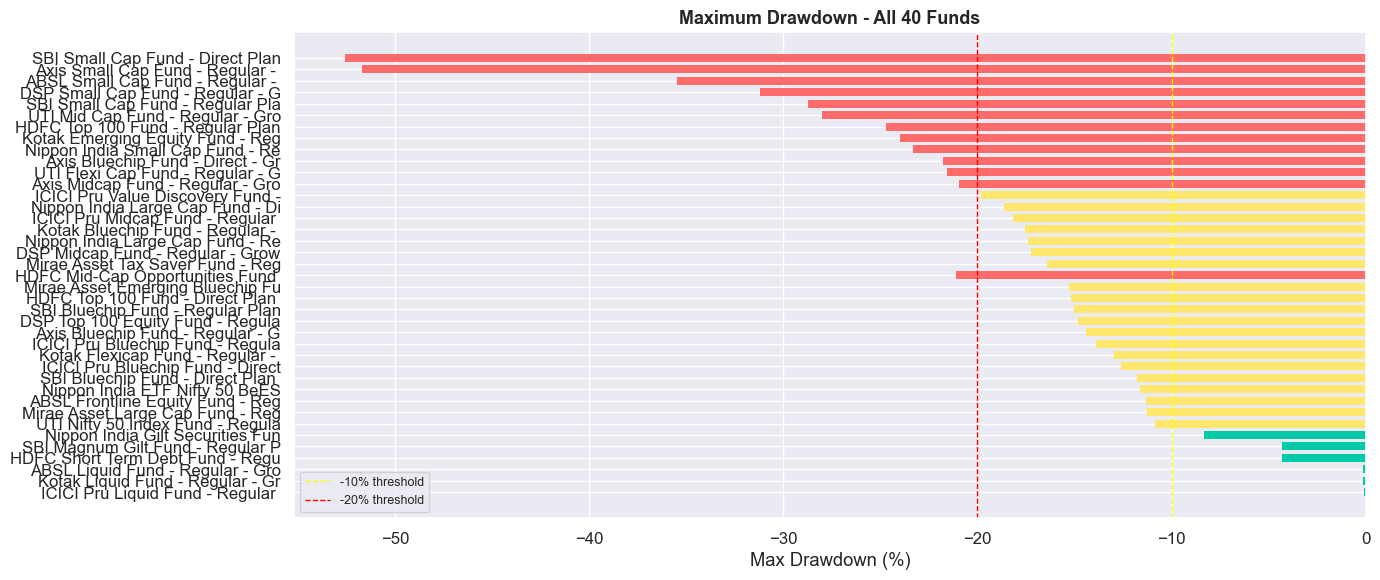

Chart saved: 15_max_drawdown.png


In [9]:
dd_rows = []
for code in nav_df['amfi_code'].unique():
    sub         = nav_df[nav_df['amfi_code'] == code].copy()
    nav_vals    = sub['nav'].values
    dates       = sub['date'].values
    running_max = np.maximum.accumulate(nav_vals)
    drawdown    = nav_vals / running_max - 1
    max_dd      = drawdown.min()
    trough_idx  = int(np.argmin(drawdown))
    peak_idx    = int(np.argmax(nav_vals[:trough_idx + 1]))
    name  = fund_df[fund_df['amfi_code'] == code]['scheme_name'].values
    plan  = fund_df[fund_df['amfi_code'] == code]['plan'].values
    dd_rows.append({
        'amfi_code'    : code,
        'scheme_name'  : name[0][:45] if len(name) else str(code),
        'plan'         : plan[0] if len(plan) else '',
        'max_drawdown_pct': round(max_dd * 100, 2),
        'peak_date'    : str(dates[peak_idx])[:10],
        'trough_date'  : str(dates[trough_idx])[:10],
        'drawdown_days': trough_idx - peak_idx,
    })

dd_df = pd.DataFrame(dd_rows).sort_values('max_drawdown_pct').reset_index(drop=True)
dd_df['dd_rank'] = range(1, len(dd_df) + 1)

print('Maximum Drawdown - Worst 10 Funds:')
print(dd_df[['scheme_name','plan','max_drawdown_pct','peak_date','trough_date','drawdown_days']].head(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(14, 6))
colors_dd = ['#FF6B6B' if d < -20 else '#FFE66D' if d < -10 else '#00C9A7' for d in dd_df['max_drawdown_pct']]
ax.barh(dd_df['scheme_name'].str[:32][::-1], dd_df['max_drawdown_pct'][::-1], color=colors_dd[::-1], edgecolor='none', height=0.7)
ax.axvline(-10, color='yellow', linestyle='--', linewidth=1.0, label='-10% threshold')
ax.axvline(-20, color='red',    linestyle='--', linewidth=1.0, label='-20% threshold')
ax.set_title('Maximum Drawdown - All 40 Funds', fontsize=13, fontweight='bold')
ax.set_xlabel('Max Drawdown (%)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(CHARTS_DIR / '15_max_drawdown.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: 15_max_drawdown.png')


---
## Task 7 - Fund Scorecard (0-100)
**Weights:** 30% x 3yr return rank + 25% x Sharpe rank + 20% x Alpha rank + 15% x Expense ratio rank (inverse) + 10% x Max DD rank (inverse)

Fund Scorecard - Top 20:
 final_rank                                           scheme_name    plan category  composite_score  cagr_3yr_pct  sharpe_ratio  alpha_ann_pct  max_drawdown_pct  expense_ratio_pct
          1              ICICI Pru Midcap Fund - Regular - Growth Regular   Equity            84.50         31.78        1.1801        29.2636            -18.19               1.36
          2                   Axis Midcap Fund - Regular - Growth Regular   Equity            80.75         35.11        0.9982        26.0767            -20.96               1.38
          3    HDFC Mid-Cap Opportunities Fund - Regular - Growth Regular   Equity            80.50         32.44        1.0937        27.1954            -16.22               1.38
          4         Mirae Asset Large Cap Fund - Regular - Growth Regular   Equity            80.00         34.00        1.4483        26.9838            -11.27               1.46
          5                Kotak Flexicap Fund - Regular - Growth Regular  

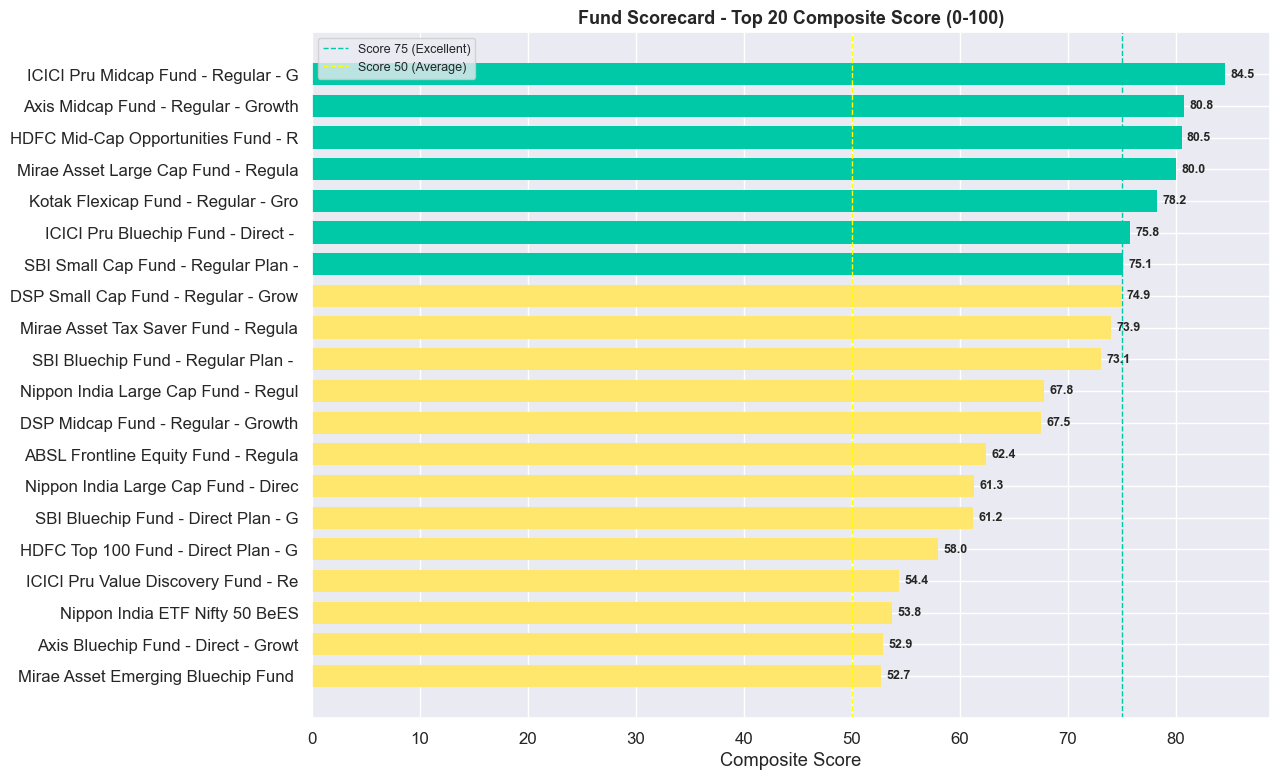

Chart saved: 16_fund_scorecard.png


In [10]:
exp_df = fund_df[['amfi_code','scheme_name','fund_house','plan','category','expense_ratio_pct']].copy()

scorecard = cagr_df[['amfi_code','scheme_name','fund_house','category','cagr_3yr_pct']].copy()
scorecard = scorecard.merge(sharpe_df[['amfi_code','sharpe_ratio']], on='amfi_code', how='left')
scorecard = scorecard.merge(sortino_df[['amfi_code','sortino_ratio']], on='amfi_code', how='left')
scorecard = scorecard.merge(ab_df[['amfi_code','alpha_ann_pct','beta']], on='amfi_code', how='left')
scorecard = scorecard.merge(dd_df[['amfi_code','max_drawdown_pct']], on='amfi_code', how='left')
scorecard = scorecard.merge(exp_df[['amfi_code','plan','expense_ratio_pct']], on='amfi_code', how='left')
scorecard = scorecard.dropna(subset=['cagr_3yr_pct','sharpe_ratio','alpha_ann_pct','max_drawdown_pct','expense_ratio_pct'])

n = len(scorecard)

scorecard['rank_3yr']     = scorecard['cagr_3yr_pct'].rank(ascending=True)  / n * 100
scorecard['rank_sharpe']  = scorecard['sharpe_ratio'].rank(ascending=True)  / n * 100
scorecard['rank_alpha']   = scorecard['alpha_ann_pct'].rank(ascending=True) / n * 100
scorecard['rank_exp_inv'] = scorecard['expense_ratio_pct'].rank(ascending=False) / n * 100
scorecard['rank_dd_inv']  = scorecard['max_drawdown_pct'].rank(ascending=False)  / n * 100

scorecard['composite_score'] = (
    0.30 * scorecard['rank_3yr']     +
    0.25 * scorecard['rank_sharpe']  +
    0.20 * scorecard['rank_alpha']   +
    0.15 * scorecard['rank_exp_inv'] +
    0.10 * scorecard['rank_dd_inv']
).round(2)

scorecard = scorecard.sort_values('composite_score', ascending=False).reset_index(drop=True)
scorecard['final_rank'] = range(1, len(scorecard) + 1)

cols_show = ['final_rank','scheme_name','plan','category','composite_score',
             'cagr_3yr_pct','sharpe_ratio','alpha_ann_pct','max_drawdown_pct','expense_ratio_pct']
print('Fund Scorecard - Top 20:')
print(scorecard[cols_show].head(20).to_string(index=False))

scorecard.to_csv(PROC_DIR / 'fund_scorecard.csv', index=False)
print('Saved: fund_scorecard.csv')

fig, ax = plt.subplots(figsize=(13, 8))
top20 = scorecard.head(20)
bar_colors = ['#00C9A7' if s >= 75 else '#FFE66D' if s >= 50 else '#FF6B6B' for s in top20['composite_score']]
bars = ax.barh(top20['scheme_name'].str[:35][::-1], top20['composite_score'][::-1], color=bar_colors[::-1], edgecolor='none', height=0.7)
for bar, val in zip(bars, top20['composite_score'][::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, str(round(val, 1)), va='center', fontsize=9, fontweight='bold')
ax.set_title('Fund Scorecard - Top 20 Composite Score (0-100)', fontsize=13, fontweight='bold')
ax.set_xlabel('Composite Score')
ax.axvline(75, color='#00C9A7', linestyle='--', linewidth=1.0, label='Score 75 (Excellent)')
ax.axvline(50, color='yellow',  linestyle='--', linewidth=1.0, label='Score 50 (Average)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(CHARTS_DIR / '16_fund_scorecard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: 16_fund_scorecard.png')


---
## Task 8 - Benchmark Comparison Chart
**Top 5 funds vs Nifty 50 and Nifty 100 over 3 years**
**Tracking Error = std(fund_return - benchmark_return) x sqrt(252)**

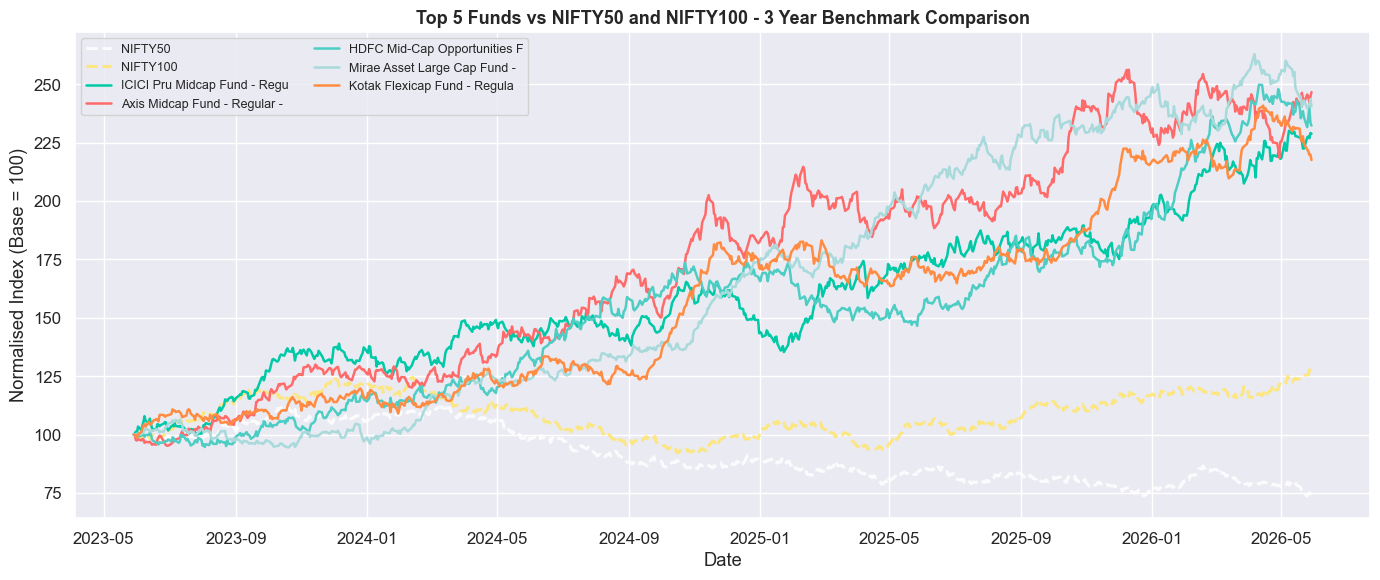

Chart saved: 17_benchmark_comparison.png
Tracking Error vs NIFTY100 (annualised):
 amfi_code                  scheme_name  tracking_error_pct
    120505 ICICI Pru Midcap Fund - Regu               23.27
    119094 Axis Midcap Fund - Regular -               23.98
    100033 HDFC Mid-Cap Opportunities F               22.50
    148567 Mirae Asset Large Cap Fund -               18.80
    120843 Kotak Flexicap Fund - Regula               20.65


In [11]:
top5_codes = scorecard.head(5)['amfi_code'].tolist()
top5_names = dict(zip(scorecard['amfi_code'], scorecard['scheme_name'].str[:28]))

cutoff_date = nav_df['date'].max() - pd.DateOffset(years=3)

nifty50  = bench_df[bench_df['index_name'] == 'NIFTY50'].copy().sort_values('date')
nifty100 = bench_df[bench_df['index_name'] == 'NIFTY100'].copy().sort_values('date')

nifty50  = nifty50[nifty50['date']  >= cutoff_date].copy()
nifty100 = nifty100[nifty100['date'] >= cutoff_date].copy()

nifty50['bench_return']  = nifty50['close_value'].pct_change()
nifty100['bench_return'] = nifty100['close_value'].pct_change()

n50_start  = nifty50['close_value'].iloc[0]
n100_start = nifty100['close_value'].iloc[0]
nifty50['norm']  = nifty50['close_value']  / n50_start  * 100
nifty100['norm'] = nifty100['close_value'] / n100_start * 100

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(nifty50['date'],  nifty50['norm'],  linewidth=2.2, color='white',  linestyle='--', label='NIFTY50',  alpha=0.85)
ax.plot(nifty100['date'], nifty100['norm'], linewidth=2.2, color='#FFE66D', linestyle='--', label='NIFTY100', alpha=0.85)

fund_colors = ['#00C9A7','#FF6B6B','#4ECDC4','#A8DADC','#FF8C42']
te_rows = []

for i, code in enumerate(top5_codes):
    sub = nav_df[(nav_df['amfi_code'] == code) & (nav_df['date'] >= cutoff_date)].copy()
    if len(sub) < 10:
        continue
    sub_start = sub['nav'].iloc[0]
    sub['norm'] = sub['nav'] / sub_start * 100
    ax.plot(sub['date'], sub['norm'], linewidth=1.8, color=fund_colors[i], label=top5_names.get(code, str(code)))

    merged = sub[['date','daily_return']].dropna().merge(nifty100[['date','bench_return']], on='date')
    if len(merged) > 50:
        te = (merged['daily_return'] - merged['bench_return']).std() * np.sqrt(TRADING_DAYS) * 100
        te_rows.append({'amfi_code': code, 'scheme_name': top5_names.get(code, str(code)), 'tracking_error_pct': round(te, 2)})

ax.set_title('Top 5 Funds vs NIFTY50 and NIFTY100 - 3 Year Benchmark Comparison', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Normalised Index (Base = 100)')
ax.legend(fontsize=9, ncol=2)
plt.tight_layout()
plt.savefig(CHARTS_DIR / '17_benchmark_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: 17_benchmark_comparison.png')

te_df = pd.DataFrame(te_rows)
if not te_df.empty:
    print('Tracking Error vs NIFTY100 (annualised):')
    print(te_df.to_string(index=False))


---
## Summary - All Deliverables

In [12]:
print('Deliverables Summary:')
print('  alpha_beta.csv      :', (PROC_DIR / 'alpha_beta.csv').exists())
print('  fund_scorecard.csv  :', (PROC_DIR / 'fund_scorecard.csv').exists())

charts = sorted(CHARTS_DIR.glob('1[0-9]_*.png'))
print('Charts generated      :', len(charts))
for c in charts:
    print('  ', c.name)

print()
print('Top 5 Funds by Composite Score:')
for _, row in scorecard.head(5).iterrows():
    print('  #' + str(row['final_rank']) + ' ' + row['scheme_name'][:40] + '  Score:' + str(row['composite_score']))

print()
print('Day 4 Performance Analytics - COMPLETE')


Deliverables Summary:
  alpha_beta.csv      : True
  fund_scorecard.csv  : True
Charts generated      : 8
   10_daily_return_distribution.png
   11_cagr_comparison.png
   12_sharpe_ratio_ranking.png
   13_sharpe_vs_sortino.png
   14_alpha_beta_scatter.png
   15_max_drawdown.png
   16_fund_scorecard.png
   17_benchmark_comparison.png

Top 5 Funds by Composite Score:
  #1 ICICI Pru Midcap Fund - Regular - Growth  Score:84.5
  #2 Axis Midcap Fund - Regular - Growth  Score:80.75
  #3 HDFC Mid-Cap Opportunities Fund - Regula  Score:80.5
  #4 Mirae Asset Large Cap Fund - Regular - G  Score:80.0
  #5 Kotak Flexicap Fund - Regular - Growth  Score:78.25

Day 4 Performance Analytics - COMPLETE
